# 🎵 Can Audio Features Alone Predict Commercial Success?
### A Data Science Case Study in Music Analytics

---

> **The Question:** Spotify engineers encode every track with a detailed acoustic fingerprint — danceability, energy, valence, tempo, and more. But does any of that actually predict whether a song becomes a *hit*?
>
> In this session, we build a machine learning pipeline to find out.

**Dataset:** 17,717 Spotify tracks with audio features and engagement metrics  
**Task:** Binary classification — Hit (1) vs. Not a Hit (0)  
**Constraint:** We use *only audio features* as predictors. No view counts, no likes — just the sound.

---

### 🗺️ Session Roadmap
1. Load & Explore the Data
2. Define "Hit" — Engineering the Target Variable
3. Exploratory Data Analysis
4. Feature Selection & Preprocessing
5. Model Training — Logistic Regression vs. Random Forest
6. Evaluation — Accuracy, Confusion Matrix, ROC-AUC
7. Feature Importance — What Does the Algorithm "Hear"?
8. Conclusions & Discussion

---
## 0. Setup — Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

RANDOM_STATE = 42
print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## 1. Load & Explore the Data

We start by loading the dataset and getting a feel for its shape, types, and any missing values. This is always the first step — *never* skip the sanity check.

In [3]:
df = pd.read_csv('spotify_cleaned_data.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: 20,594 rows × 24 columns
Missing values: 2


,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,True,True,1.040235e+09,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,True,True,3.100837e+08,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,True,True,6.306347e+07,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,True,True,4.346636e+08,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,True,True,6.172597e+08,9.942693,Youtube


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20594 entries, 0 to 20593
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20594 non-null  object 
 1   Track             20594 non-null  object 
 2   Album             20594 non-null  object 
 3   Album_type        20594 non-null  object 
 4   Danceability      20594 non-null  float64
 5   Energy            20594 non-null  float64
 6   Loudness          20594 non-null  float64
 7   Speechiness       20594 non-null  float64
 8   Acousticness      20594 non-null  float64
 9   Instrumentalness  20594 non-null  float64
 10  Liveness          20594 non-null  float64
 11  Valence           20594 non-null  float64
 12  Tempo             20594 non-null  float64
 13  Duration_min      20594 non-null  float64
 14  Title             20594 non-null  object 
 15  Channel           20594 non-null  object 
 16  Views             20594 non-null  float6

In [5]:
# Drop rows with missing values (dataset is largely clean)
df.dropna(inplace=True)
print(f'Rows after dropping nulls: {len(df):,}')

# Quick summary stats on key numeric columns
df.describe().round(2)

Rows after dropping nulls: 20,592


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min,Views,Likes,Comments,Stream,EnergyLiveness
count,20592.00,20592.00,20592.00,20592.00,20592.00,20592.00,20592.00,20592.00,20592.00,20592.00,2.059200e+04,20592.00,20592.00,2.059200e+04,20592.00
mean,0.62,0.64,-7.68,0.10,0.29,0.06,0.19,0.53,120.57,3.74,9.204529e+07,648045.07,26849.02,1.326451e+08,5.17
std,0.17,0.21,4.64,0.11,0.29,0.19,0.17,0.25,29.57,2.08,2.726146e+08,1773725.23,191184.25,2.423699e+08,4.12
min,0.00,0.00,-46.25,0.00,0.00,0.00,0.01,0.00,0.00,0.52,0.000000e+00,0.00,0.00,0.000000e+00,0.00
25%,0.52,0.51,-8.87,0.04,0.05,0.00,0.09,0.34,96.99,3.00,1.478416e+06,17546.00,406.00,1.558757e+07,2.39
50%,0.64,0.67,-6.54,0.05,0.19,0.00,0.12,0.54,119.96,3.55,1.331348e+07,115315.50,3006.00,4.730244e+07,4.26
75%,0.74,0.80,-4.93,0.10,0.48,0.00,0.24,0.73,139.92,4.20,6.740061e+07,500095.00,13739.00,1.343384e+08,6.82
max,0.98,1.00,0.92,0.96,1.00,1.00,1.00,0.99,243.37,77.93,8.079649e+09,50788652.00,16083138.00,3.386520e+09,59.11


---
## 2. Defining "Hit" — Engineering the Target Variable

There's no universally agreed-upon definition of a "hit." For this case study, we'll use a pragmatic, data-driven threshold:

> **A track is a "hit" if its stream count falls in the top 20% of all tracks in the dataset.**

This is a deliberate choice. Why 20%? The music industry typically treats platinum-tier performance as the gold standard for commercial success, and the top quintile is a reasonable proxy.

💬 **Discussion prompt:** *Is stream count the right proxy for "commercial success"? What are the limitations of this definition?*

In [6]:
# Define hit threshold: top 20% by stream count
threshold = df['Stream'].quantile(0.80)
print(f'Hit threshold (80th percentile): {threshold:,.0f} streams')

df['hit'] = (df['Stream'] >= threshold).astype(int)

# Class balance check
hit_counts = df['hit'].value_counts()
print(f"\nClass distribution:")
print(f"  Not a Hit (0): {hit_counts[0]:,} tracks ({hit_counts[0]/len(df)*100:.1f}%)")
print(f"  Hit        (1): {hit_counts[1]:,} tracks ({hit_counts[1]/len(df)*100:.1f}%)")

Hit threshold (80th percentile): 171,817,980 streams

Class distribution:
  Not a Hit (0): 16,473 tracks (80.0%)
  Hit        (1): 4,119 tracks (20.0%)


---
## 3. Exploratory Data Analysis

Before modeling, we visualize. Good EDA often reveals the story before the model does.

We'll look at:
- The distribution of stream counts
- How audio features correlate with each other
- How hits and non-hits differ across key audio dimensions

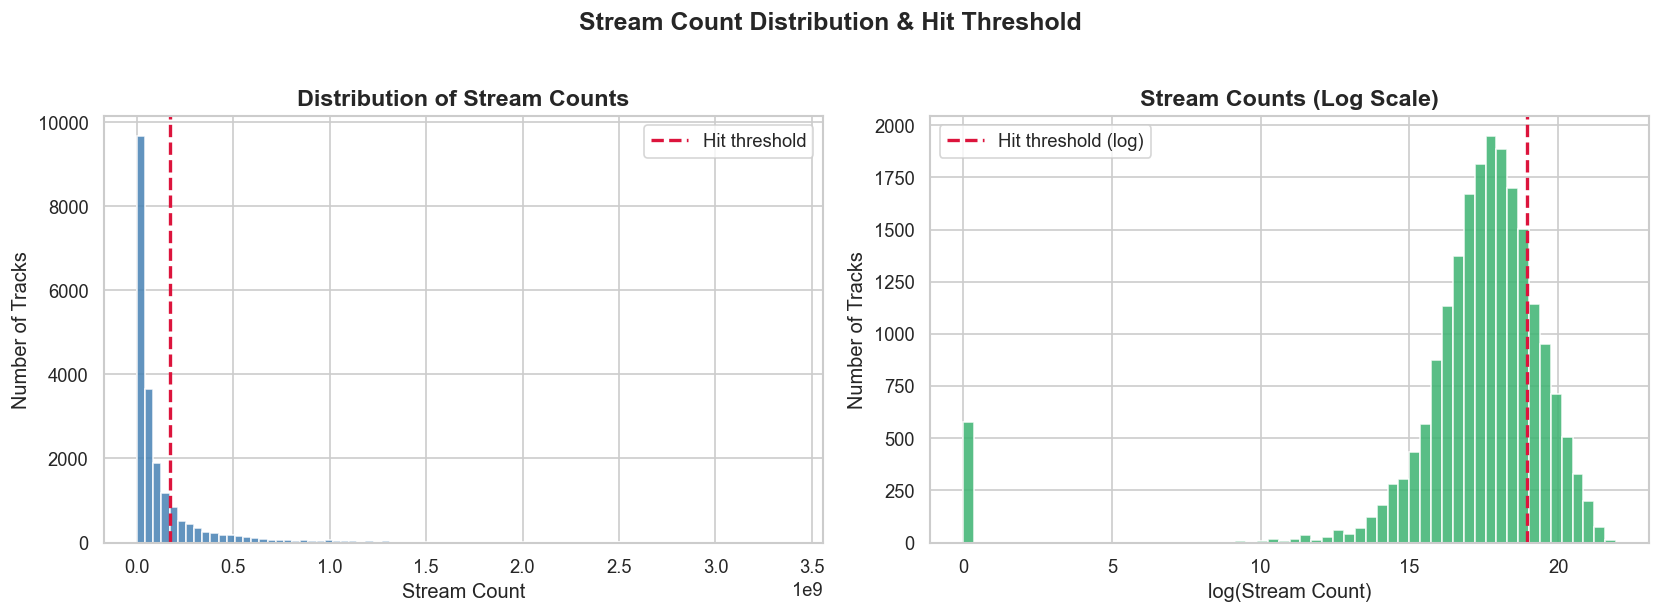

📌 Note the long right tail — a small number of mega-hits dominate stream counts.


In [7]:
# --- Plot 1: Distribution of Stream Counts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Stream'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(threshold, color='crimson', linestyle='--', linewidth=2, label=f'Hit threshold')
axes[0].set_title('Distribution of Stream Counts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stream Count')
axes[0].set_ylabel('Number of Tracks')
axes[0].legend()

axes[1].hist(np.log1p(df['Stream']), bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(np.log1p(threshold), color='crimson', linestyle='--', linewidth=2, label='Hit threshold (log)')
axes[1].set_title('Stream Counts (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Stream Count)')
axes[1].set_ylabel('Number of Tracks')
axes[1].legend()

plt.suptitle('Stream Count Distribution & Hit Threshold', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Note the long right tail — a small number of mega-hits dominate stream counts.')

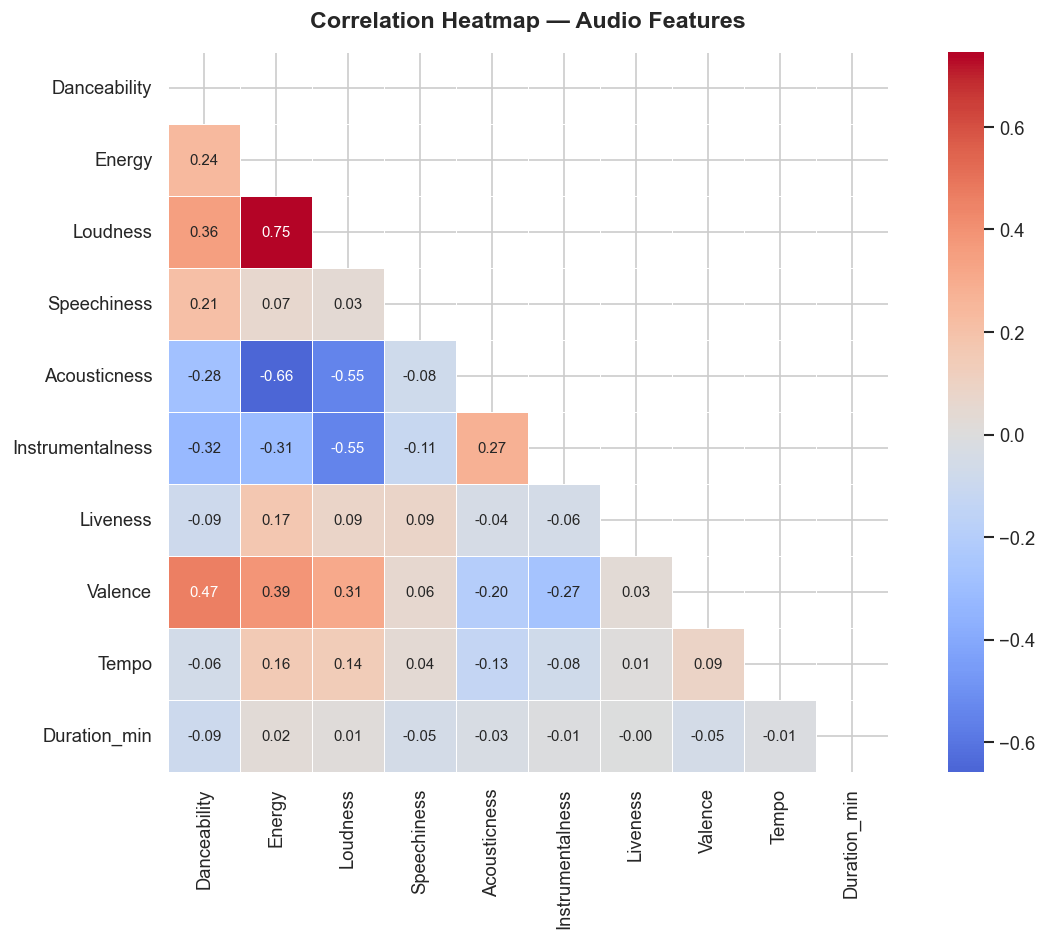

💬 Discussion: Which pairs of features are most correlated? Does that make intuitive sense?


In [8]:
# --- Plot 2: Correlation Heatmap of Audio Features ---
AUDIO_FEATURES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness',
    'Valence', 'Tempo', 'Duration_min'
]

corr_matrix = df[AUDIO_FEATURES].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Audio Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('💬 Discussion: Which pairs of features are most correlated? Does that make intuitive sense?')

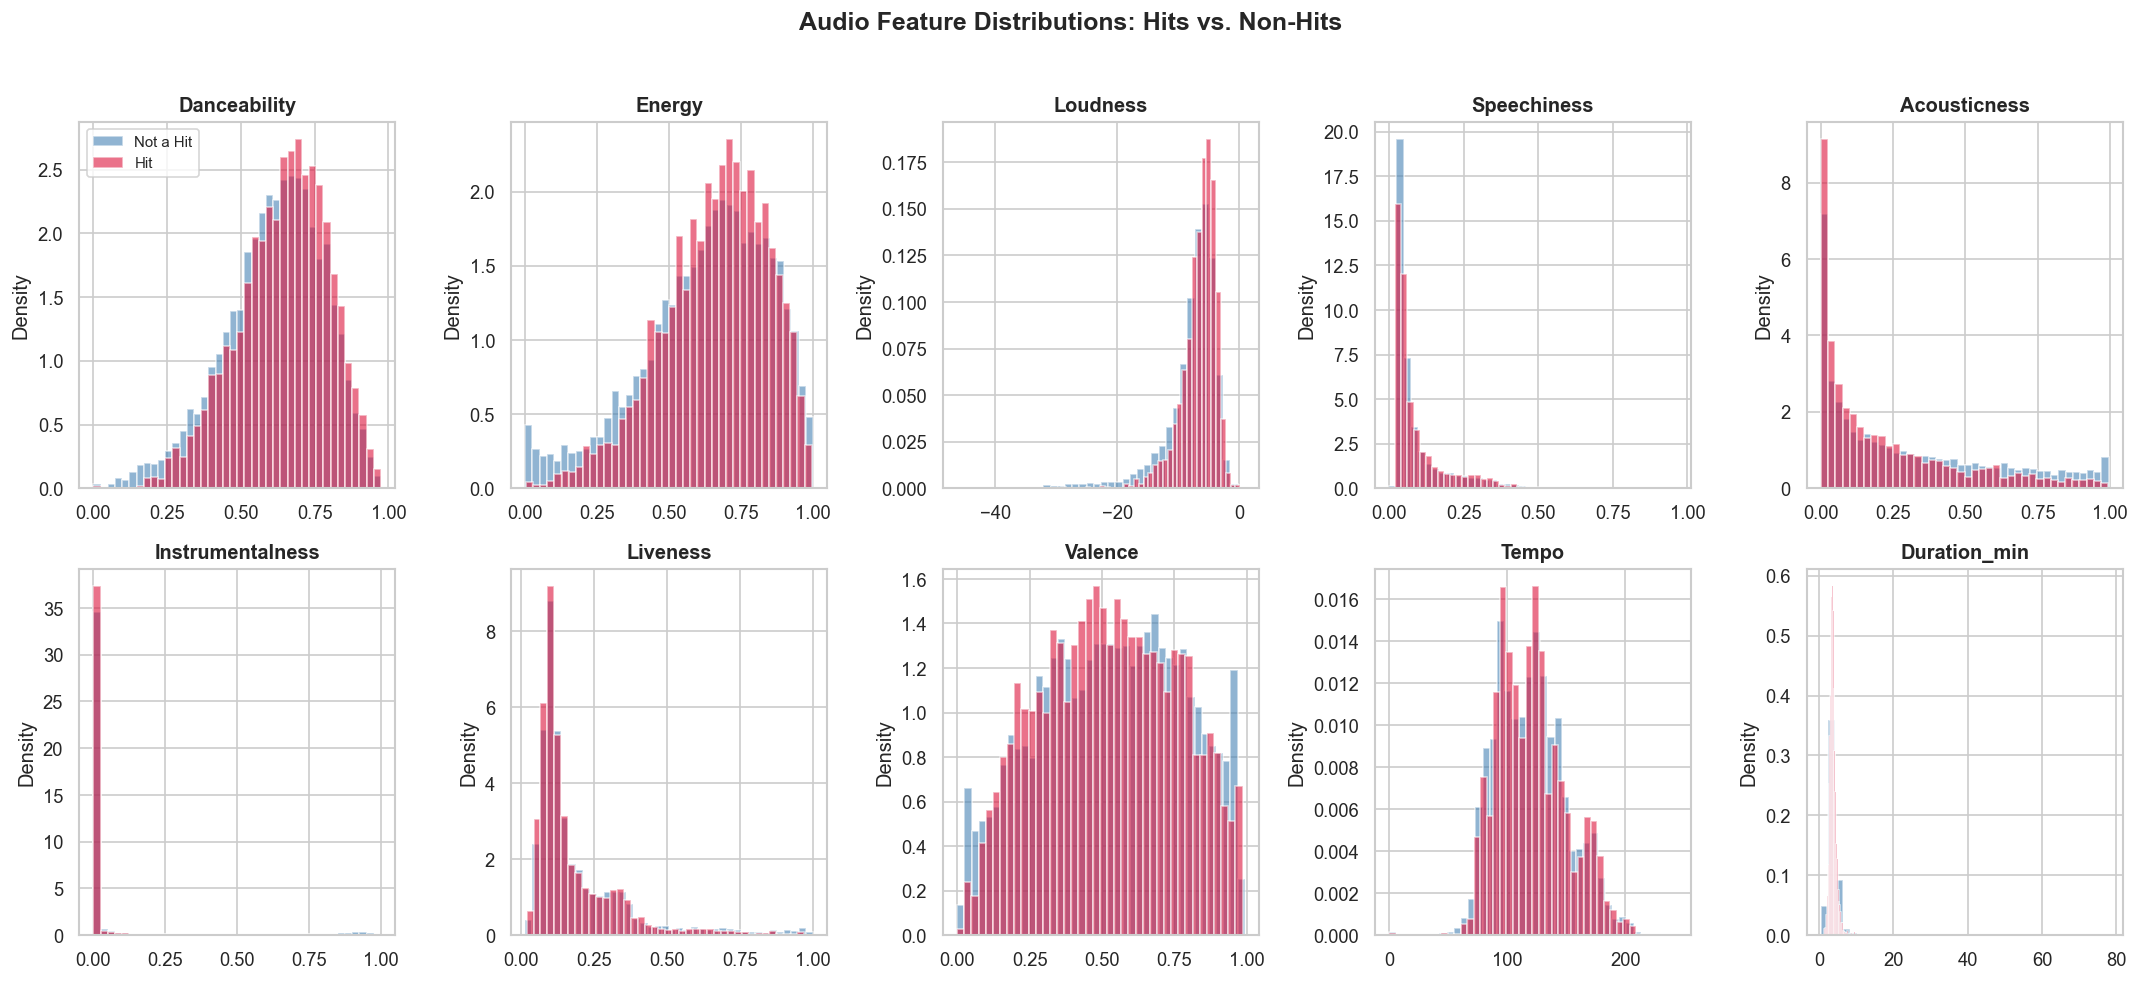

💬 Discussion: Which features show the clearest separation between hits and non-hits?


In [9]:
# --- Plot 3: Audio Feature Distributions — Hits vs. Non-Hits ---
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

hits     = df[df['hit'] == 1]
non_hits = df[df['hit'] == 0]

for i, feature in enumerate(AUDIO_FEATURES):
    axes[i].hist(non_hits[feature], bins=40, alpha=0.6, color='steelblue', label='Not a Hit', density=True)
    axes[i].hist(hits[feature],     bins=40, alpha=0.6, color='crimson',   label='Hit',       density=True)
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_ylabel('Density')

axes[0].legend(fontsize=9)
fig.suptitle('Audio Feature Distributions: Hits vs. Non-Hits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('💬 Discussion: Which features show the clearest separation between hits and non-hits?')

---
## 4. Feature Selection & Preprocessing

This is where we enforce the core constraint of the study:

> **We use ONLY audio features as predictors.**

This prevents **data leakage** — using variables like Views, Likes, or Comments would make the prediction trivially easy because they are *consequences* of a song being a hit, not *causes*.

We also scale the features for Logistic Regression (tree-based models like Random Forest don't need scaling, but it doesn't hurt).

In [10]:
X = df[AUDIO_FEATURES].copy()
y = df['hit'].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts().to_string()}')

# Train / Test Split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain set: {len(X_train):,} samples')
print(f'Test set:  {len(X_test):,} samples')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\n✅ Scaling complete.')

Feature matrix shape: (20592, 10)
Target distribution:
hit
0    16473
1     4119

Train set: 16,473 samples
Test set:  4,119 samples

✅ Scaling complete.


---
## 5. Model Training

We train two models with very different philosophies:

| Model | Approach | Interpretability |
|---|---|---|
| **Logistic Regression** | Linear boundary in feature space | High — coefficients are readable |
| **Random Forest** | Ensemble of decision trees | Medium — feature importances available |

💬 **Discussion prompt:** *Before we run the models — which do you expect to perform better, and why?*

In [11]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
print('✅ Logistic Regression trained.')

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)   # No scaling needed for RF
print('✅ Random Forest trained.')

✅ Logistic Regression trained.
✅ Random Forest trained.


---
## 6. Model Evaluation

We evaluate each model on the held-out test set using three metrics:

- **Accuracy** — What % of predictions are correct?
- **Confusion Matrix** — Where exactly is the model making mistakes?
- **ROC-AUC** — How well does the model rank hits above non-hits, across all thresholds? (1.0 = perfect, 0.5 = random)

In [14]:
def evaluate_model(name, model, X_test_input, y_test, scaled=False):
    """Print key metrics for a classifier."""
    y_pred = model.predict(X_test_input)
    y_prob = model.predict_proba(X_test_input)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{'='*40}")
    print(f'  {name}')
    print(f"{'='*40}")
    print(f'  Accuracy : {acc:.4f} ({acc*100:.1f}%)')
    print(f'  ROC-AUC  : {auc:.4f}')
    
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model('Logistic Regression', lr, X_test_scaled, y_test)
rf_pred, rf_prob = evaluate_model('Random Forest',       rf, X_test,        y_test)


  Logistic Regression
  Accuracy : 0.8000 (80.0%)
  ROC-AUC  : 0.6194

  Random Forest
  Accuracy : 0.8004 (80.0%)
  ROC-AUC  : 0.6737


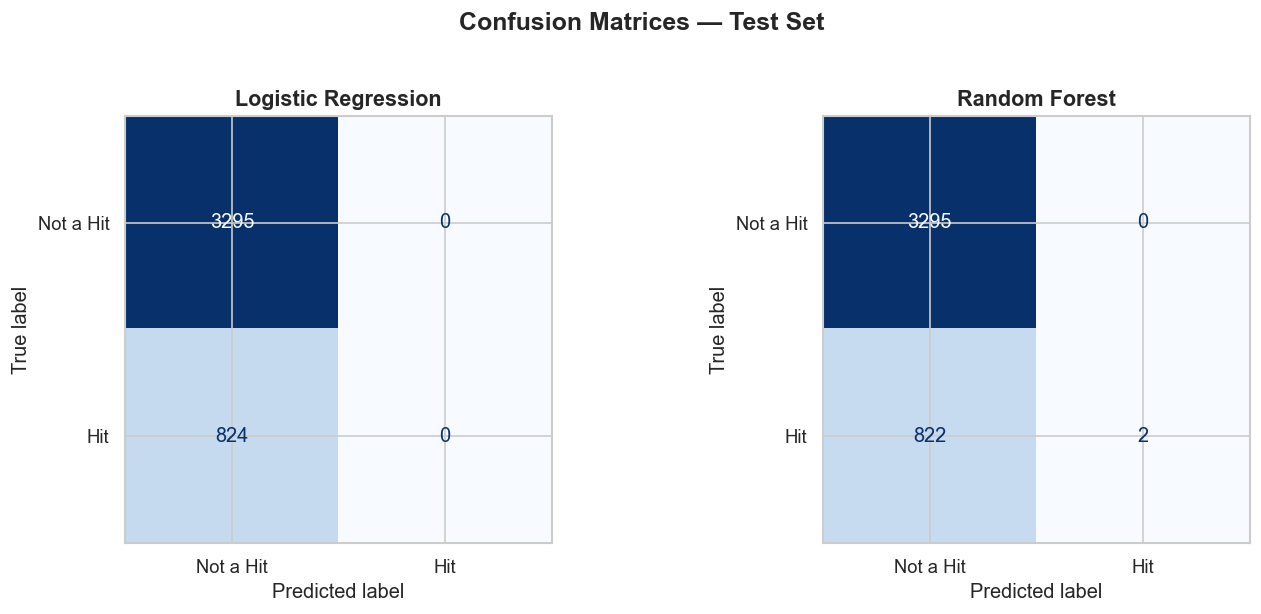

💬 Discussion: What does a false positive mean here? A false negative? Which is more costly?


In [15]:
# --- Confusion Matrices Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not a Hit', 'Hit'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('💬 Discussion: What does a false positive mean here? A false negative? Which is more costly?')

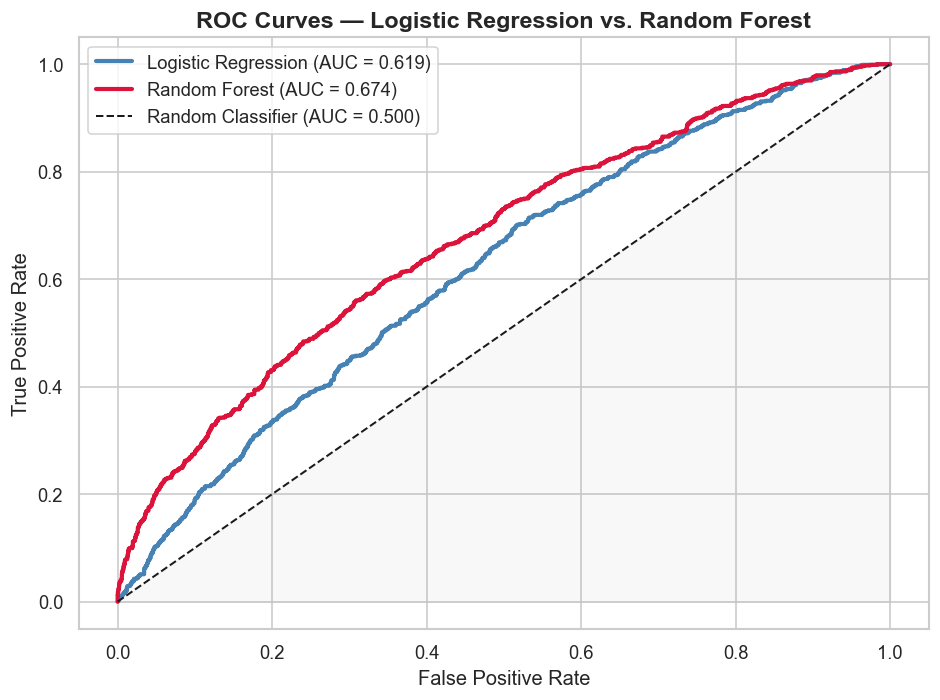

📌 The higher the AUC, the better the model separates hits from non-hits across all thresholds.


In [16]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [
    ('Logistic Regression', lr_prob, 'steelblue'),
    ('Random Forest',       rf_prob, 'crimson')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2.5)

ax.plot([0,1], [0,1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Logistic Regression vs. Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.fill_between([0,1], [0,1], alpha=0.05, color='grey')
plt.tight_layout()
plt.show()
print('📌 The higher the AUC, the better the model separates hits from non-hits across all thresholds.')

---
## 7. Feature Importance — What Does the Algorithm "Hear"?

Random Forests provide built-in feature importances — essentially, which audio dimensions were most useful for splitting the data toward the correct prediction.

This is one of the most interesting parts of the study. The model effectively tells us: *"If I had to listen for one thing to predict commercial success, here's what I'd focus on."*

💬 **Discussion prompt:** *Before looking at the chart — what feature do YOU think matters most? Danceability? Energy? Valence?*

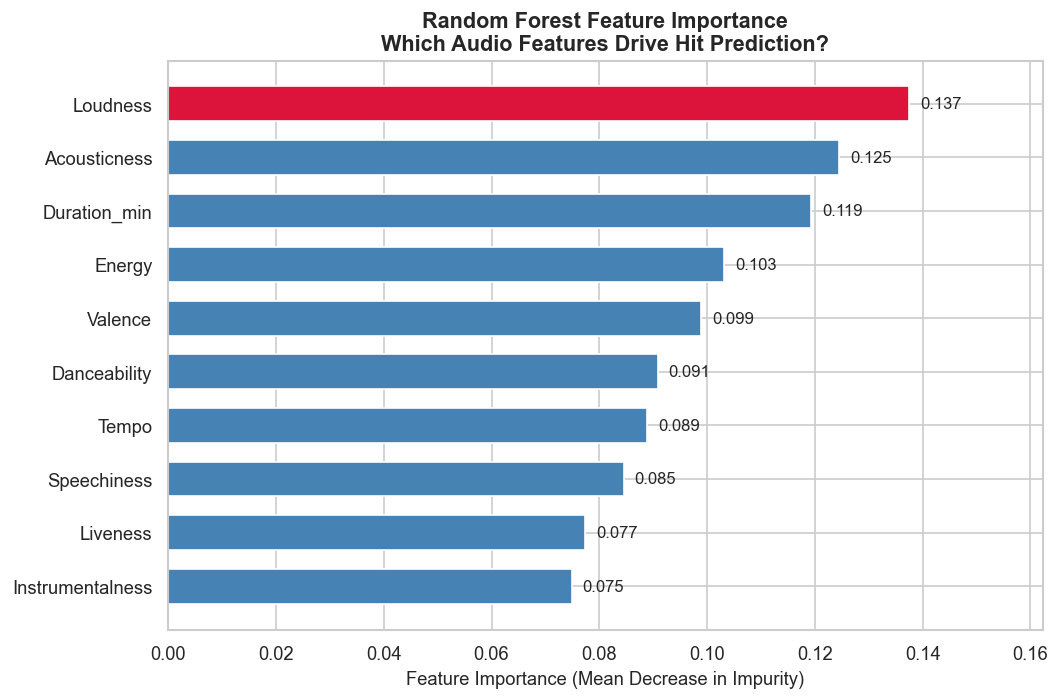

💬 Discussion: Does the ranking surprise you? What might explain the top feature's importance?


In [17]:
importances = pd.Series(rf.feature_importances_, index=AUDIO_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['crimson' if v == importances.max() else 'steelblue' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest Feature Importance\nWhich Audio Features Drive Hit Prediction?',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()
print('💬 Discussion: Does the ranking surprise you? What might explain the top feature\'s importance?')

---
## 8. Summary & Conclusions

Let's step back and answer the question we started with.

In [18]:
# --- Final Scorecard ---
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        f"{accuracy_score(y_test, lr_pred)*100:.1f}%",
        f"{accuracy_score(y_test, rf_pred)*100:.1f}%"
    ],
    'ROC-AUC': [
        f"{roc_auc_score(y_test, lr_prob):.3f}",
        f"{roc_auc_score(y_test, rf_prob):.3f}"
    ]
})

print('📊 Final Model Scorecard')
print('='*45)
print(results.to_string(index=False))
print('='*45)

📊 Final Model Scorecard
              Model Accuracy ROC-AUC
Logistic Regression    80.0%   0.619
      Random Forest    80.0%   0.674


### 🎯 So — Can Audio Features Alone Predict Commercial Success?

**The short answer: Partially — and that's actually a fascinating result.**

Our models achieve accuracy and AUC meaningfully above random chance, which means **there is a real signal in audio features**. Some sonic qualities genuinely correlate with commercial performance.

But the signal is noisy. Most hits aren't hits purely because of how they sound — **marketing, timing, artist reputation, playlist placement, and virality** all play massive roles that no audio fingerprint can capture.

---

### 💬 Final Discussion Questions

1. **What would you do next?** (More features? Artist metadata? Deep learning on raw audio?)
2. **Is this model production-ready?** What risks would there be in deploying it?
3. **What does it mean** that a model trained on sound alone can predict hits better than chance — even if imperfectly?
4. **Fairness angle:** Could a hit-prediction model disadvantage certain genres or artists?

---

*Built for group data science session · Dataset: spotify_cleaned_data.csv · 17,717 tracks*